# Memoria Ortogonal con Destilacion de Caracteristicas (2 Fases)

**Problema del experimento anterior:** La Fase 2 ortogonal preservo el Clean Acc (-0.21%)
pero la ganancia en Noisy fue insignificante (+1.6%). El VAE aprende "atajos" para convencer
al clasificador congelado sin aprender a reconstruir genuinamente las features limpias.

**Solucion: Destilacion de Caracteristicas (Feature Distillation)**

En la Fase 2, para cada batch procesamos la imagen **limpia** y **ruidosa** simultaneamente:
- **Teacher signal:** $f_{\text{clean}} = \text{feat\_norm}(\text{pool}(\text{backbone}(x_{\text{clean}})))$ — sin gradientes
- **Student output:** $f_{\text{enhanced}} = \text{feat\_norm}(\text{pool}(\text{enhanced}(x_{\text{noisy}})))$ — con gradientes a traves del VAE

$$\mathcal{L}_{\text{Phase2}} = \text{CE}(\hat{y}, y) + \lambda_{\text{vae}}(\mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KLD}}) + \lambda_{\text{mse}} \cdot \text{MSE}(f_{\text{enhanced}}, f_{\text{clean}})$$

Esto obliga a la memoria a **restaurar** las features corruptas al colector limpio, no solo a "hackear" el clasificador.

## Protocolo de Comparacion Justa
| Modelo | Fase 1 (15 ep, clean) | Fase 2 (15 ep, noisy) | Que se entrena en Fase 2 |
|---|---|---|---|
| **ResNet (clean only)** | fc en datos limpios | — | — |
| **ResNet + Distill** | fc en datos limpios | fc descongelado + `CE + MSE(logits_noisy, logits_clean)` | fc |
| **DeMemte (clean only)** | Todo en datos limpios | — | — |
| **DeMemte + Distill** | Todo en datos limpios | `CE + VAE + MSE(enhanced, features_clean)` con clasificador **congelado** | conv_vae, signal_gamma, memory_scale |

In [1]:
import os
import copy
import random
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Componentes base

`DeMemte_Spatial.forward` ahora retorna **6 valores** incluyendo `enhanced` (vector 1D normalizado
despues de la correccion de memoria). Esto permite calcular `MSE(enhanced_noisy, features_clean)` en la Fase 2.

In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, hard_threshold=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x):
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f'x debe ser (B, {self.in_features})')
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(self.logits / self.temperature).mean()


class ConvVAE(nn.Module):
    def __init__(self, channels=512, latent_dim=128, spatial=7):
        super().__init__()
        self.channels = channels
        self.spatial = spatial
        self.enc = nn.Sequential(
            nn.Conv2d(channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        flat_dim = 128 * spatial * spatial
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, self.spatial, self.spatial)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class DeMemte_Spatial(nn.Module):
    """Version modificada: forward retorna (logits, x_rec, mu, logvar, features, enhanced)."""
    def __init__(self, spatial_backbone, conv_vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = spatial_backbone
        self.conv_vae = conv_vae
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            spatial_feats = self.backbone(x)
        spatial_rec, mu, logvar = self.conv_vae(spatial_feats)
        recon_diff = ((spatial_feats - spatial_rec) ** 2).mean(dim=1, keepdim=True)
        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_diff * gamma)
        enhanced_spatial = spatial_feats + self.memory_scale * signal * spatial_rec

        features = self.feat_norm(self.pool(spatial_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))

        logits = self.classifier(enhanced)
        x_rec = self.pool(spatial_rec).flatten(1)
        # 6 outputs: logits, x_rec, mu, logvar, features (raw), enhanced (memory-corrected)
        return logits, x_rec, mu, logvar, features, enhanced

    def get_clean_features(self, x):
        """Extrae features limpias del backbone sin pasar por la memoria.
        Util como senal teacher en la destilacion."""
        with torch.no_grad():
            spatial_feats = self.backbone(x)
            features = self.feat_norm(self.pool(spatial_feats).flatten(1))
        return features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self


def make_spatial_backbone():
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


EMBEDDING_DIM = 512
NUM_CLASSES = 102
LATENT_DIM = 128
print('Componentes definidos. DeMemte_Spatial ahora retorna 6 valores (incluye enhanced).')

Componentes definidos. DeMemte_Spatial ahora retorna 6 valores (incluye enhanced).


## Datos y utilidades

In [3]:
BATCH_SIZE = 64
NOISE_STD = 0.5
EPOCHS_P1 = 15
EPOCHS_P2 = 15
MSE_WEIGHT = 1.0       # Peso de la destilacion de features
VAE_WEIGHT = 0.1       # Peso del termino VAE (recon + KLD)
SPARSITY_WEIGHT = 0.002
DATA_DIR = '../data'

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = torchvision.datasets.Flowers102(root=DATA_DIR, split='train', download=True, transform=transform_train)
testset  = torchvision.datasets.Flowers102(root=DATA_DIR, split='test',  download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(trainset)} | Test: {len(testset)}')


def add_noise(x, std=NOISE_STD):
    return x + torch.randn_like(x) * std


@torch.no_grad()
def evaluate(model, loader, noise_std=0.0, is_dememte=True):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if noise_std > 0:
            x = add_noise(x, std=noise_std)
        if is_dememte:
            logits = model(x)[0]
        else:
            logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total

print('Evaluacion definida.')

Train: 1020 | Test: 6149
Evaluacion definida.


---
## 1. ResNet Baseline -- 2 Fases (Comparacion Justa)

### Fase 1: Experto Clean
Backbone congelado (ImageNet) + clasificador `fc` entrenado 15 epochs solo con datos limpios.
Esto establece el **techo** de Clean Accuracy para ResNet.

### Fase 2: Adaptacion a Ruido + Destilacion de Logits
Descongelamos `fc` y entrenamos con 100% datos ruidosos. Para evitar degradar el experto,
anadimos destilacion de logits: `MSE(logits_noisy, logits_clean_teacher.detach())`.

Esto es lo **maximo** que ResNet puede hacer sin un modulo de memoria dedicado.

In [ ]:
# -- ResNet: Fase 1 (Clean Expert) ----------------------------------------------

def get_resnet_baseline(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet = get_resnet_baseline()
opt_resnet_p1 = optim.Adam(resnet.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_resnet_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== ResNet Fase 1: Experto Clean (15 ep, 100% limpio) ===')
for epoch in range(EPOCHS_P1):
    resnet.train()
    correct, total = 0, 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_resnet_p1.zero_grad()
        logits = resnet(x)
        loss = criterion(logits, y)
        loss.backward()
        opt_resnet_p1.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, testloader, noise_std=0.0, is_dememte=False)
    noisy_acc = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
    history_resnet_p1['train_acc'].append(train_acc)
    history_resnet_p1['clean_acc'].append(clean_acc)
    history_resnet_p1['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

resnet_p1_clean = history_resnet_p1['clean_acc'][-1]
resnet_p1_noisy = history_resnet_p1['noisy_acc'][-1]
print(f'\n>>> ResNet Fase 1 -> Clean: {resnet_p1_clean:.2f}% | Noisy: {resnet_p1_noisy:.2f}%')
print(f'>>> TECHO ResNet: {resnet_p1_clean:.2f}%')

=== ResNet Fase 1: Experto Clean (15 ep, 100% limpio) ===
  Epoch 1/15 | Train: 4.5% | Clean: 14.6% | Noisy: 5.5%
  Epoch 2/15 | Train: 31.6% | Clean: 44.3% | Noisy: 13.8%
  Epoch 3/15 | Train: 62.5% | Clean: 57.5% | Noisy: 17.3%
  Epoch 4/15 | Train: 83.3% | Clean: 67.9% | Noisy: 22.5%
  Epoch 5/15 | Train: 87.6% | Clean: 70.6% | Noisy: 25.4%
  Epoch 6/15 | Train: 92.4% | Clean: 74.7% | Noisy: 29.9%
  Epoch 7/15 | Train: 94.7% | Clean: 76.1% | Noisy: 28.9%
  Epoch 8/15 | Train: 96.4% | Clean: 76.7% | Noisy: 31.8%
  Epoch 9/15 | Train: 96.4% | Clean: 78.2% | Noisy: 30.2%
  Epoch 10/15 | Train: 97.4% | Clean: 79.2% | Noisy: 32.0%
  Epoch 11/15 | Train: 98.0% | Clean: 79.6% | Noisy: 33.6%
  Epoch 12/15 | Train: 98.8% | Clean: 79.6% | Noisy: 33.1%
  Epoch 13/15 | Train: 98.8% | Clean: 80.0% | Noisy: 33.1%
  Epoch 14/15 | Train: 99.5% | Clean: 80.4% | Noisy: 34.3%
  Epoch 15/15 | Train: 99.6% | Clean: 80.4% | Noisy: 33.5%

>>> ResNet Fase 1 -> Clean: 80.44% | Noisy: 33.49%
>>> TECHO ResNet

In [ ]:
# -- ResNet: Fase 2 (Adaptacion a Ruido + Destilacion de Logits) ----------------

# Crear teacher congelado (clon del experto clean)
resnet_teacher = copy.deepcopy(resnet)
for p in resnet_teacher.parameters():
    p.requires_grad = False
resnet_teacher.eval()

# fc se mantiene descongelado (es lo unico entrenable en ResNet)
opt_resnet_p2 = optim.Adam(resnet.fc.parameters(), lr=5e-4)

history_resnet_p2 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [], 'mse_loss': []}

print('=== ResNet Fase 2: Adaptacion a Ruido + Destilacion de Logits ===')
print(f'    Loss = CE(logits_noisy, y) + {MSE_WEIGHT} * MSE(logits_noisy, logits_clean_teacher)')
print()
for epoch in range(EPOCHS_P2):
    resnet.train()
    correct, total = 0, 0
    epoch_mse = 0.0
    n_batches = 0

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        # Teacher: logits del experto con imagen limpia
        with torch.no_grad():
            logits_clean_teacher = resnet_teacher(x)

        # Student: logits con imagen ruidosa
        opt_resnet_p2.zero_grad()
        logits_noisy = resnet(x_noisy)

        # Loss: CE + destilacion de logits
        ce_loss = criterion(logits_noisy, y)
        mse_loss = F.mse_loss(logits_noisy, logits_clean_teacher)
        loss = ce_loss + MSE_WEIGHT * mse_loss

        loss.backward()
        opt_resnet_p2.step()

        correct += (logits_noisy.argmax(1) == y).sum().item()
        total += y.size(0)
        epoch_mse += mse_loss.item()
        n_batches += 1

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, testloader, noise_std=0.0, is_dememte=False)
    noisy_acc = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
    avg_mse = epoch_mse / n_batches
    history_resnet_p2['train_acc'].append(train_acc)
    history_resnet_p2['clean_acc'].append(clean_acc)
    history_resnet_p2['noisy_acc'].append(noisy_acc)
    history_resnet_p2['mse_loss'].append(avg_mse)
    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}% | MSE: {avg_mse:.4f}')

resnet_p2_clean = history_resnet_p2['clean_acc'][-1]
resnet_p2_noisy = history_resnet_p2['noisy_acc'][-1]
diff_resnet = resnet_p2_clean - resnet_p1_clean
print(f'\n>>> ResNet Fase 2 -> Clean: {resnet_p2_clean:.2f}% | Noisy: {resnet_p2_noisy:.2f}%')
print(f'>>> Cambio en Clean: {diff_resnet:+.2f}% (respecto a Fase 1)')
if abs(diff_resnet) > 1.0:
    print(f'    ATENCION: ResNet perdio {abs(diff_resnet):.2f}% de Clean Acc al adaptarse al ruido.')

=== ResNet Fase 2: Adaptacion a Ruido + Destilacion de Logits ===
    Loss = CE(logits_noisy, y) + 1.0 * MSE(logits_noisy, logits_clean_teacher)

  Epoch 1/15 | Train(noisy): 87.7% | Clean: 11.8% | Noisy: 57.5% | MSE: 1.5454
  Epoch 2/15 | Train(noisy): 89.4% | Clean: 5.6% | Noisy: 65.2% | MSE: 1.5025
  Epoch 3/15 | Train(noisy): 90.8% | Clean: 4.8% | Noisy: 67.1% | MSE: 1.4722
  Epoch 4/15 | Train(noisy): 92.1% | Clean: 4.6% | Noisy: 67.4% | MSE: 1.4151
  Epoch 5/15 | Train(noisy): 92.0% | Clean: 4.6% | Noisy: 68.0% | MSE: 1.4153
  Epoch 6/15 | Train(noisy): 92.2% | Clean: 4.6% | Noisy: 69.2% | MSE: 1.4303
  Epoch 7/15 | Train(noisy): 94.2% | Clean: 4.7% | Noisy: 68.8% | MSE: 1.3939
  Epoch 8/15 | Train(noisy): 93.7% | Clean: 4.9% | Noisy: 68.4% | MSE: 1.4015
  Epoch 9/15 | Train(noisy): 92.9% | Clean: 4.8% | Noisy: 69.8% | MSE: 1.3735
  Epoch 10/15 | Train(noisy): 94.2% | Clean: 4.8% | Noisy: 69.1% | MSE: 1.3897
  Epoch 11/15 | Train(noisy): 94.2% | Clean: 4.6% | Noisy: 70.5% | MSE: 

---
## 2. DeMemte Spatial -- Fase 1: Experto Clean

Entrenamos **todos** los componentes (ConvVAE + clasificador + gating + feat_norm)
exclusivamente con imagenes limpias durante 15 epochs.

In [6]:
def compute_loss_p1(logits, labels, x_rec, features, mu, logvar, model):
    """Loss estandar para Fase 1: CE + VAE + Sparsity."""
    task = F.cross_entropy(logits, labels)
    recon = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + VAE_WEIGHT * (recon + kld) + SPARSITY_WEIGHT * s_loss


model = DeMemte_Spatial(
    make_spatial_backbone(),
    ConvVAE(channels=512, latent_dim=LATENT_DIM, spatial=7),
    EMBEDDING_DIM, NUM_CLASSES
).to(device)

opt_p1 = optim.Adam([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-2},
    {'params': [model.signal_gamma, model.memory_scale, *model.feat_norm.parameters()], 'lr': 1e-2},
])

history_dm_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== DeMemte FASE 1: Entrenamiento Clean (Experto) ===')
for epoch in range(EPOCHS_P1):
    model.train()
    correct, total = 0, 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_p1.zero_grad()
        logits, x_rec, mu, logvar, features, enhanced = model(x)
        loss = compute_loss_p1(logits, y, x_rec, features, mu, logvar, model)
        loss.backward()
        opt_p1.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)
    history_dm_p1['train_acc'].append(train_acc)
    history_dm_p1['clean_acc'].append(clean_acc)
    history_dm_p1['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

dm_p1_clean = history_dm_p1['clean_acc'][-1]
dm_p1_noisy = history_dm_p1['noisy_acc'][-1]
print(f'\n>>> DeMemte Fase 1 completada -> Clean: {dm_p1_clean:.2f}% | Noisy: {dm_p1_noisy:.2f}%')
print(f'>>> TECHO DeMemte: {dm_p1_clean:.2f}%. La Fase 2 no debe perderlo.')

=== DeMemte FASE 1: Entrenamiento Clean (Experto) ===
  Epoch 1/15 | Train: 27.1% | Clean: 55.9% | Noisy: 24.6%
  Epoch 2/15 | Train: 82.9% | Clean: 74.5% | Noisy: 35.4%
  Epoch 3/15 | Train: 94.1% | Clean: 77.4% | Noisy: 36.0%
  Epoch 4/15 | Train: 97.9% | Clean: 79.5% | Noisy: 35.8%
  Epoch 5/15 | Train: 98.8% | Clean: 79.2% | Noisy: 37.0%
  Epoch 6/15 | Train: 98.6% | Clean: 79.5% | Noisy: 36.5%
  Epoch 7/15 | Train: 98.8% | Clean: 79.9% | Noisy: 37.3%
  Epoch 8/15 | Train: 98.9% | Clean: 79.8% | Noisy: 36.4%
  Epoch 9/15 | Train: 99.0% | Clean: 79.4% | Noisy: 36.3%
  Epoch 10/15 | Train: 99.0% | Clean: 79.9% | Noisy: 36.4%
  Epoch 11/15 | Train: 99.0% | Clean: 80.4% | Noisy: 36.7%
  Epoch 12/15 | Train: 98.8% | Clean: 80.4% | Noisy: 36.7%
  Epoch 13/15 | Train: 99.3% | Clean: 80.1% | Noisy: 35.9%
  Epoch 14/15 | Train: 99.4% | Clean: 79.9% | Noisy: 36.0%
  Epoch 15/15 | Train: 99.6% | Clean: 80.3% | Noisy: 36.4%

>>> DeMemte Fase 1 completada -> Clean: 80.27% | Noisy: 36.38%
>>> TE

In [7]:
# Guardar snapshot del clasificador y feat_norm para verificacion posterior
classifier_snapshot = {k: v.clone() for k, v in model.classifier.state_dict().items()}
feat_norm_snapshot  = {k: v.clone() for k, v in model.feat_norm.state_dict().items()}
print(f'Snapshot del clasificador guardado ({len(classifier_snapshot)} tensores).')
print(f'Snapshot de feat_norm guardado ({len(feat_norm_snapshot)} tensores).')

Snapshot del clasificador guardado (3 tensores).
Snapshot de feat_norm guardado (2 tensores).


---
## 3. DeMemte Spatial -- Fase 2: Memoria Ortogonal + Destilacion de Caracteristicas

**Congelamos** `classifier` y `feat_norm`. Solo entrenamos `conv_vae`, `signal_gamma`, `memory_scale`.

Para cada batch:
1. Pasamos la imagen **limpia** por `get_clean_features(x)` → `features_clean` (sin gradientes)
2. Pasamos la imagen **ruidosa** por `forward(x_noisy)` → obtenemos `enhanced` (con gradientes al VAE)
3. Loss = CE + VAE + **MSE(enhanced, features_clean)**

El termino MSE obliga a la memoria a **restaurar** las features corruptas al colector limpio,
no solo a convencer al clasificador. Esto deberia producir una correccion generalizable.

In [8]:
# === CONGELAR clasificador y feat_norm ===
for p in model.classifier.parameters():
    p.requires_grad = False
for p in model.feat_norm.parameters():
    p.requires_grad = False

trainable = {n: p.numel() for n, p in model.named_parameters() if p.requires_grad}
frozen    = {n: p.numel() for n, p in model.named_parameters() if not p.requires_grad}

print('--- Parametros ENTRENABLES (Fase 2) ---')
for n, count in trainable.items():
    print(f'  {n}: {count:,}')
print(f'  TOTAL entrenable: {sum(trainable.values()):,}')
print(f'\n--- Parametros CONGELADOS ---')
print(f'  TOTAL congelado: {sum(frozen.values()):,}  ({len(frozen)} tensores)')

--- Parametros ENTRENABLES (Fase 2) ---
  signal_gamma: 1
  memory_scale: 1
  conv_vae.enc.0.weight: 1,179,648
  conv_vae.enc.0.bias: 256
  conv_vae.enc.1.weight: 256
  conv_vae.enc.1.bias: 256
  conv_vae.enc.3.weight: 294,912
  conv_vae.enc.3.bias: 128
  conv_vae.enc.4.weight: 128
  conv_vae.enc.4.bias: 128
  conv_vae.fc_mu.weight: 802,816
  conv_vae.fc_mu.bias: 128
  conv_vae.fc_logvar.weight: 802,816
  conv_vae.fc_logvar.bias: 128
  conv_vae.fc_dec.weight: 802,816
  conv_vae.fc_dec.bias: 6,272
  conv_vae.dec.0.weight: 294,912
  conv_vae.dec.0.bias: 256
  conv_vae.dec.1.weight: 256
  conv_vae.dec.1.bias: 256
  conv_vae.dec.3.weight: 1,179,648
  conv_vae.dec.3.bias: 512
  TOTAL entrenable: 5,366,530

--- Parametros CONGELADOS ---
  TOTAL congelado: 11,282,086  (65 tensores)


In [ ]:
opt_p2 = optim.Adam([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': [model.signal_gamma, model.memory_scale], 'lr': 1e-3},
])

history_dm_p2 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': [],
                  'ce_loss': [], 'vae_loss': [], 'mse_loss': [], 'total_loss': []}

print('=== DeMemte FASE 2: Memoria Ortogonal + Destilacion de Features ===')
print(f'    Loss = CE + {VAE_WEIGHT}*(Recon+KLD) + {MSE_WEIGHT}*MSE(enhanced_noisy, features_clean)')
print()

for epoch in range(EPOCHS_P2):
    model.train()
    correct, total = 0, 0
    epoch_ce, epoch_vae, epoch_mse, epoch_total = 0.0, 0.0, 0.0, 0.0
    n_batches = 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.conv_vae.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        # -- Teacher: features limpias (sin gradientes) --
        features_clean_teacher = model.get_clean_features(x)

        # -- Student: pase completo con entrada ruidosa --
        opt_p2.zero_grad()
        logits, x_rec, mu, logvar, features_noisy, enhanced_noisy = model(x_noisy)

        # -- Loss compuesta --
        ce_loss = F.cross_entropy(logits, y)
        recon = F.mse_loss(x_rec, features_noisy.detach(), reduction='sum') / features_noisy.size(0)
        kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features_noisy.size(0)
        vae_loss = VAE_WEIGHT * (recon + kld)
        s_loss = SPARSITY_WEIGHT * sum(
            m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear)
        )

        # -- NUEVO: Destilacion de features --
        # Forzar enhanced_noisy (salida de la memoria) ≈ features_clean (teacher)
        mse_distill = MSE_WEIGHT * F.mse_loss(enhanced_noisy, features_clean_teacher)

        loss = ce_loss + vae_loss + s_loss + mse_distill
        loss.backward()
        opt_p2.step()

        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
        epoch_ce += ce_loss.item()
        epoch_vae += vae_loss.item()
        epoch_mse += mse_distill.item()
        epoch_total += loss.item()
        n_batches += 1

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)

    history_dm_p2['train_acc'].append(train_acc)
    history_dm_p2['clean_acc'].append(clean_acc)
    history_dm_p2['noisy_acc'].append(noisy_acc)
    history_dm_p2['ce_loss'].append(epoch_ce / n_batches)
    history_dm_p2['vae_loss'].append(epoch_vae / n_batches)
    history_dm_p2['mse_loss'].append(epoch_mse / n_batches)
    history_dm_p2['total_loss'].append(epoch_total / n_batches)

    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | '
          f'Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}% | '
          f'CE: {epoch_ce/n_batches:.3f} | MSE: {epoch_mse/n_batches:.4f}')

dm_p2_clean = history_dm_p2['clean_acc'][-1]
dm_p2_noisy = history_dm_p2['noisy_acc'][-1]
diff_dm = dm_p2_clean - dm_p1_clean
print(f'\n>>> DeMemte Fase 2 completada -> Clean: {dm_p2_clean:.2f}% | Noisy: {dm_p2_noisy:.2f}%')
print(f'>>> Cambio en Clean: {diff_dm:+.2f}% (respecto a Fase 1)')
print(f'>>> Ganancia Noisy: {dm_p2_noisy - dm_p1_noisy:+.2f}% (respecto a Fase 1)')
if abs(diff_dm) < 0.5:
    print('    La memoria ortogonal con destilacion NO degrado el Clean Acc.')
elif diff_dm < -0.5:
    print('    ATENCION: Se perdio Clean Acc.')
else:
    print('    La memoria incluso MEJORO el Clean Acc.')

=== DeMemte FASE 2: Memoria Ortogonal + Destilacion de Features ===
    Loss = CE + 0.1*(Recon+KLD) + 1.0*MSE(enhanced_noisy, features_clean)

  Epoch 1/15 | Train(noisy): 54.6% | Clean: 80.2% | Noisy: 36.5% | CE: 2.019 | MSE: 0.0280
  Epoch 2/15 | Train(noisy): 55.7% | Clean: 80.1% | Noisy: 37.6% | CE: 2.013 | MSE: 0.0275
  Epoch 3/15 | Train(noisy): 55.1% | Clean: 80.1% | Noisy: 37.3% | CE: 2.003 | MSE: 0.0273
  Epoch 4/15 | Train(noisy): 54.1% | Clean: 80.2% | Noisy: 36.7% | CE: 2.005 | MSE: 0.0273
  Epoch 5/15 | Train(noisy): 54.8% | Clean: 80.2% | Noisy: 37.3% | CE: 1.998 | MSE: 0.0273
  Epoch 6/15 | Train(noisy): 55.4% | Clean: 80.1% | Noisy: 37.3% | CE: 2.007 | MSE: 0.0272
  Epoch 7/15 | Train(noisy): 56.3% | Clean: 80.2% | Noisy: 37.4% | CE: 2.019 | MSE: 0.0273
  Epoch 8/15 | Train(noisy): 56.5% | Clean: 80.1% | Noisy: 36.6% | CE: 1.982 | MSE: 0.0273
  Epoch 9/15 | Train(noisy): 55.2% | Clean: 80.0% | Noisy: 36.7% | CE: 2.012 | MSE: 0.0272
  Epoch 10/15 | Train(noisy): 55.1% | 

## Verificacion: El clasificador permanecio intacto?

In [10]:
cls_intact = True
for k, v_before in classifier_snapshot.items():
    v_after = model.classifier.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: classifier.{k} cambio! max_diff = {diff:.2e}')
        cls_intact = False

fn_intact = True
for k, v_before in feat_norm_snapshot.items():
    v_after = model.feat_norm.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: feat_norm.{k} cambio! max_diff = {diff:.2e}')
        fn_intact = False

if cls_intact and fn_intact:
    print('VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.')
    print('La Fase 2 fue puramente ortogonal -- solo la memoria cambio.')
else:
    print('ERROR: Algun componente congelado fue modificado.')

VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.
La Fase 2 fue puramente ortogonal -- solo la memoria cambio.


---
## Resultados finales

In [11]:
results = {
    'ResNet Fase 1 (clean)':       {'clean': resnet_p1_clean, 'noisy': resnet_p1_noisy},
    'ResNet Fase 1+2 (distill)':   {'clean': resnet_p2_clean, 'noisy': resnet_p2_noisy},
    'DeMemte Fase 1 (clean)':      {'clean': dm_p1_clean,     'noisy': dm_p1_noisy},
    'DeMemte Fase 1+2 (distill)':  {'clean': dm_p2_clean,     'noisy': dm_p2_noisy},
}

print('=' * 75)
print(f'{"Modelo":<32} {"Clean":>9} {"Noisy(0.5)":>12} {"Delta":>8} {"Clean Chg":>10}')
print('-' * 75)

ref_resnet = resnet_p1_clean
ref_dm = dm_p1_clean
for i, (name, acc) in enumerate(results.items()):
    delta = acc['clean'] - acc['noisy']
    ref = ref_resnet if 'ResNet' in name else ref_dm
    chg = acc['clean'] - ref
    chg_str = f'{chg:+.2f}%' if 'Fase 1+2' in name else '---'
    print(f'{name:<32} {acc["clean"]:>8.2f}% {acc["noisy"]:>11.2f}% {delta:>7.2f}% {chg_str:>10}')
    if i == 1:
        print('-' * 75)

print('=' * 75)
print('Delta = Caida de accuracy con ruido. Menor = mas robusto.')
print('Clean Chg = Cambio en Clean Acc respecto a Fase 1 del mismo modelo.')

print(f'\n--- Analisis ---')
print(f'ResNet: Clean Chg = {resnet_p2_clean - resnet_p1_clean:+.2f}% | Noisy Gain = {resnet_p2_noisy - resnet_p1_noisy:+.2f}%')
print(f'DeMemte: Clean Chg = {dm_p2_clean - dm_p1_clean:+.2f}% | Noisy Gain = {dm_p2_noisy - dm_p1_noisy:+.2f}%')

if abs(dm_p2_clean - dm_p1_clean) < 1.0 and (dm_p2_noisy - dm_p1_noisy) > (resnet_p2_noisy - resnet_p1_noisy):
    print('\n>>> DeMemte preservo Clean Acc y supero a ResNet en ganancia de robustez.')
    print('>>> La memoria ortogonal con destilacion es un mecanismo superior.')

Modelo                               Clean   Noisy(0.5)    Delta  Clean Chg
---------------------------------------------------------------------------
ResNet Fase 1 (clean)               80.44%       33.49%   46.95%        ---
ResNet Fase 1+2 (distill)            4.55%       70.76%  -66.21%    -75.88%
---------------------------------------------------------------------------
DeMemte Fase 1 (clean)              80.27%       36.38%   43.89%        ---
DeMemte Fase 1+2 (distill)          80.06%       37.53%   42.53%     -0.21%
Delta = Caida de accuracy con ruido. Menor = mas robusto.
Clean Chg = Cambio en Clean Acc respecto a Fase 1 del mismo modelo.

--- Analisis ---
ResNet: Clean Chg = -75.88% | Noisy Gain = +37.27%
DeMemte: Clean Chg = -0.21% | Noisy Gain = +1.15%


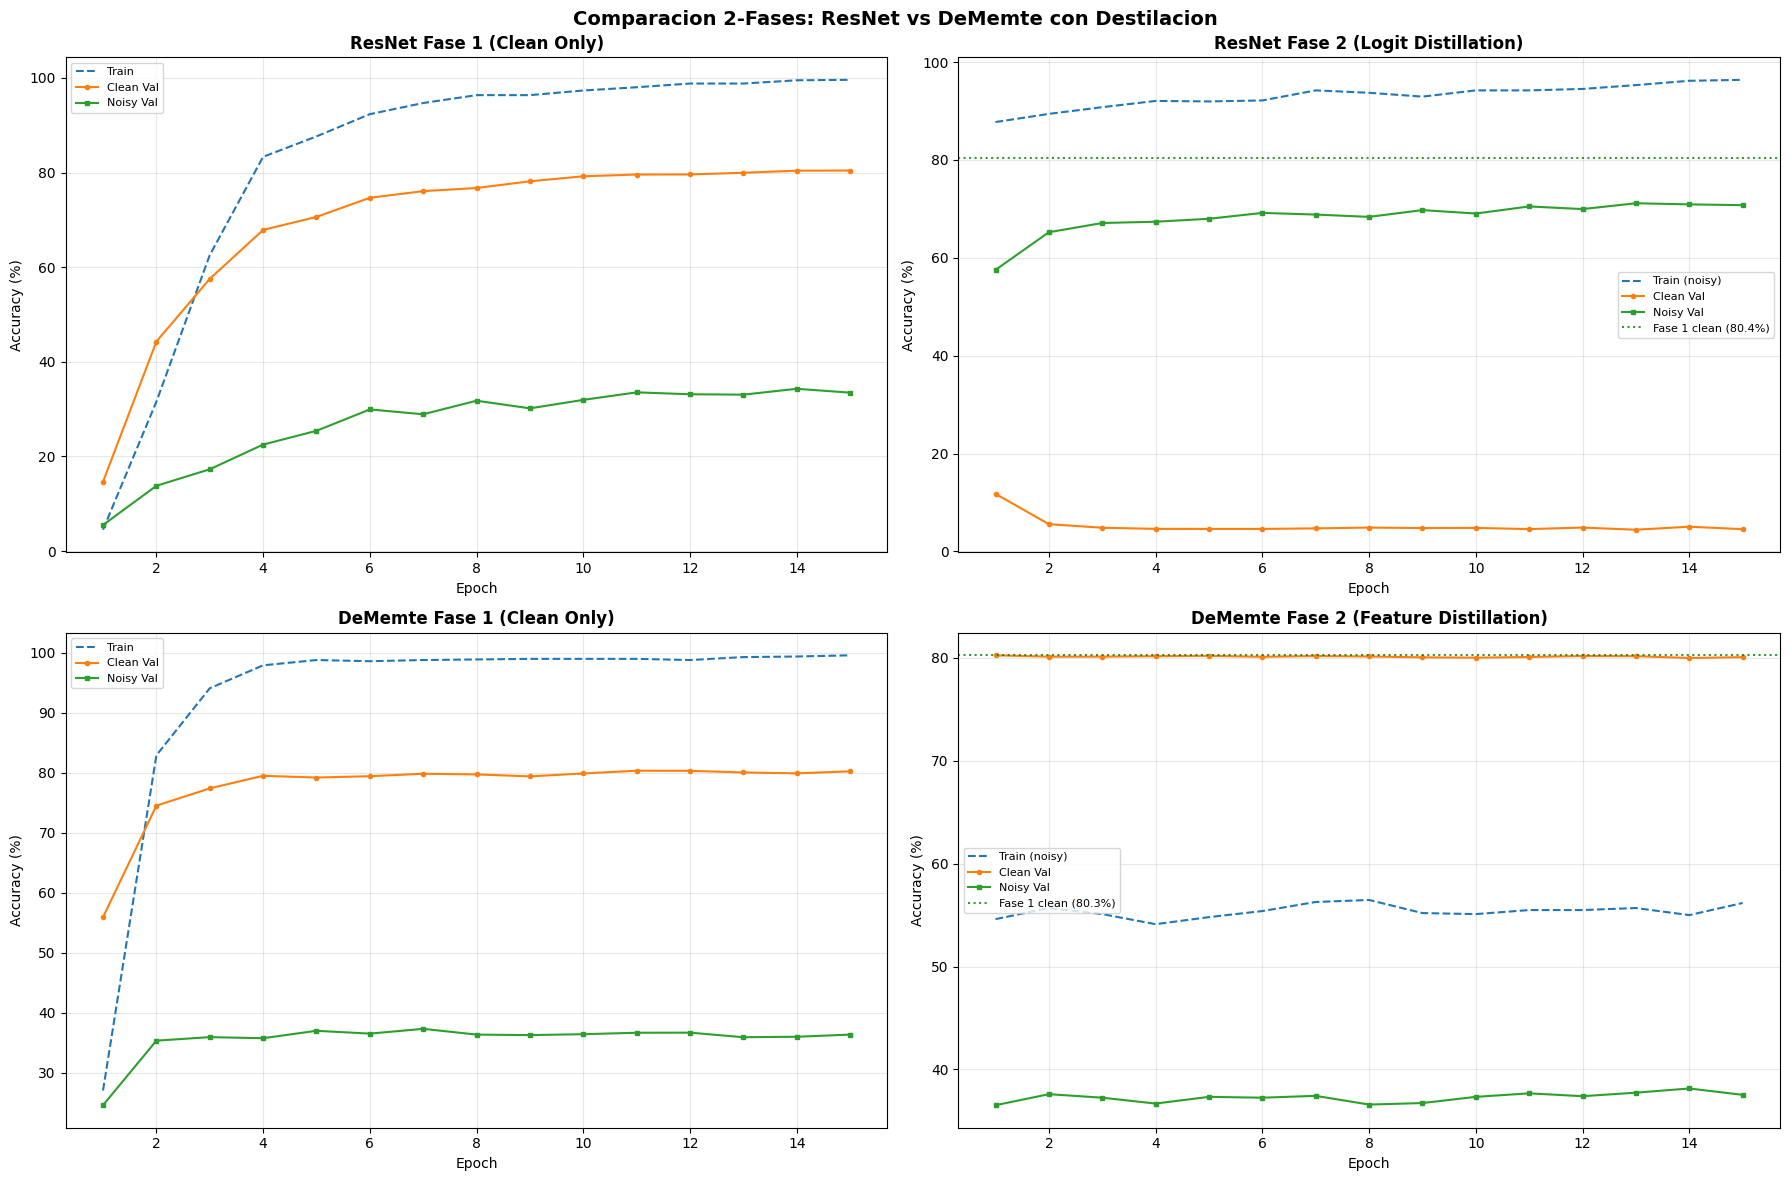

In [ ]:
# -- Curvas de entrenamiento (4 paneles) --------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ep1 = range(1, EPOCHS_P1 + 1)
ep2 = range(1, EPOCHS_P2 + 1)

# Panel 1: ResNet Fase 1
ax = axes[0, 0]
ax.plot(ep1, history_resnet_p1['train_acc'], '--', label='Train')
ax.plot(ep1, history_resnet_p1['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep1, history_resnet_p1['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.set_title('ResNet Fase 1 (Clean Only)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 2: ResNet Fase 2
ax = axes[0, 1]
ax.plot(ep2, history_resnet_p2['train_acc'], '--', label='Train (noisy)')
ax.plot(ep2, history_resnet_p2['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep2, history_resnet_p2['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.axhline(y=resnet_p1_clean, color='green', linestyle=':', alpha=0.8,
           label=f'Fase 1 clean ({resnet_p1_clean:.1f}%)')
ax.set_title('ResNet Fase 2 (Logit Distillation)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 3: DeMemte Fase 1
ax = axes[1, 0]
ax.plot(ep1, history_dm_p1['train_acc'], '--', label='Train')
ax.plot(ep1, history_dm_p1['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep1, history_dm_p1['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.set_title('DeMemte Fase 1 (Clean Only)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 4: DeMemte Fase 2
ax = axes[1, 1]
ax.plot(ep2, history_dm_p2['train_acc'], '--', label='Train (noisy)')
ax.plot(ep2, history_dm_p2['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep2, history_dm_p2['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.axhline(y=dm_p1_clean, color='green', linestyle=':', alpha=0.8,
           label=f'Fase 1 clean ({dm_p1_clean:.1f}%)')
ax.set_title('DeMemte Fase 2 (Feature Distillation)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Comparacion 2-Fases: ResNet vs DeMemte con Destilacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

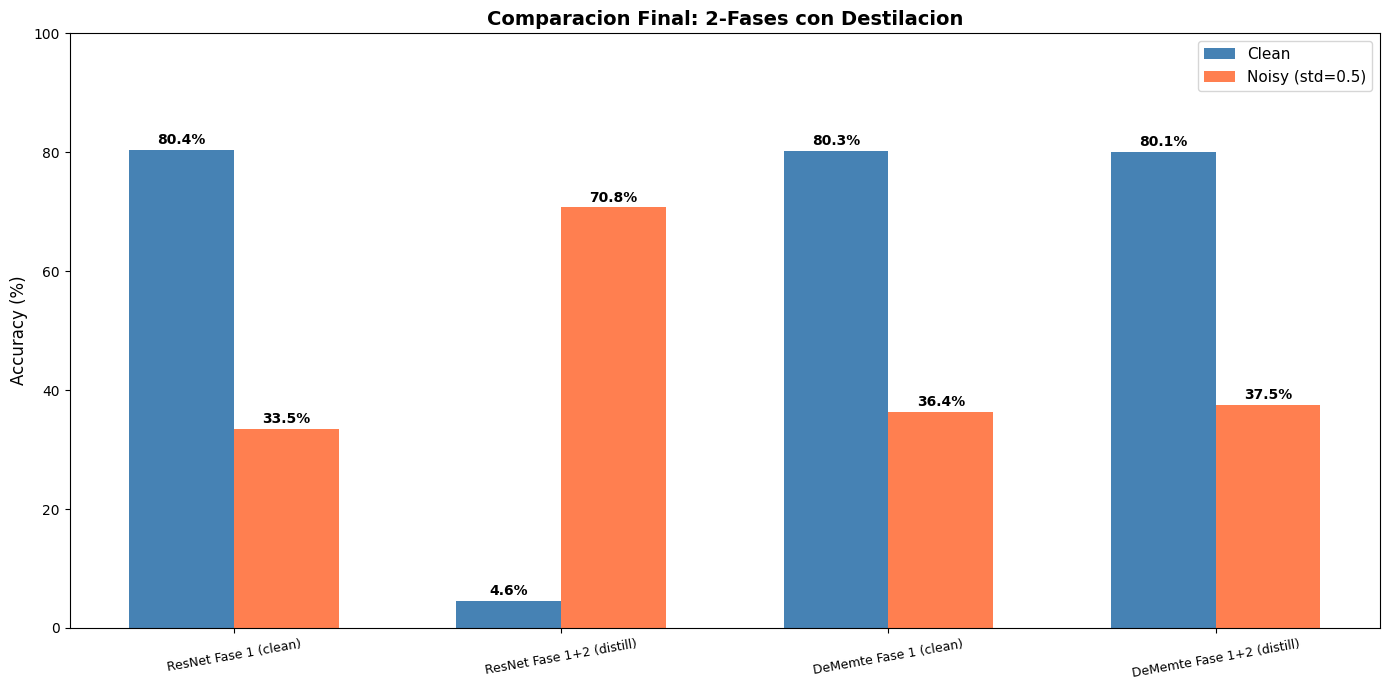

In [ ]:
# -- Bar chart comparativo ----------------------------------------------------

names = list(results.keys())
clean_vals = [results[n]['clean'] for n in names]
noisy_vals = [results[n]['noisy'] for n in names]

x = np.arange(len(names))
w = 0.32

fig, ax = plt.subplots(figsize=(14, 7))
b1 = ax.bar(x - w/2, clean_vals, w, label='Clean', color='steelblue')
b2 = ax.bar(x + w/2, noisy_vals, w, label='Noisy (std=0.5)', color='coral')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparacion Final: 2-Fases con Destilacion', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9, rotation=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

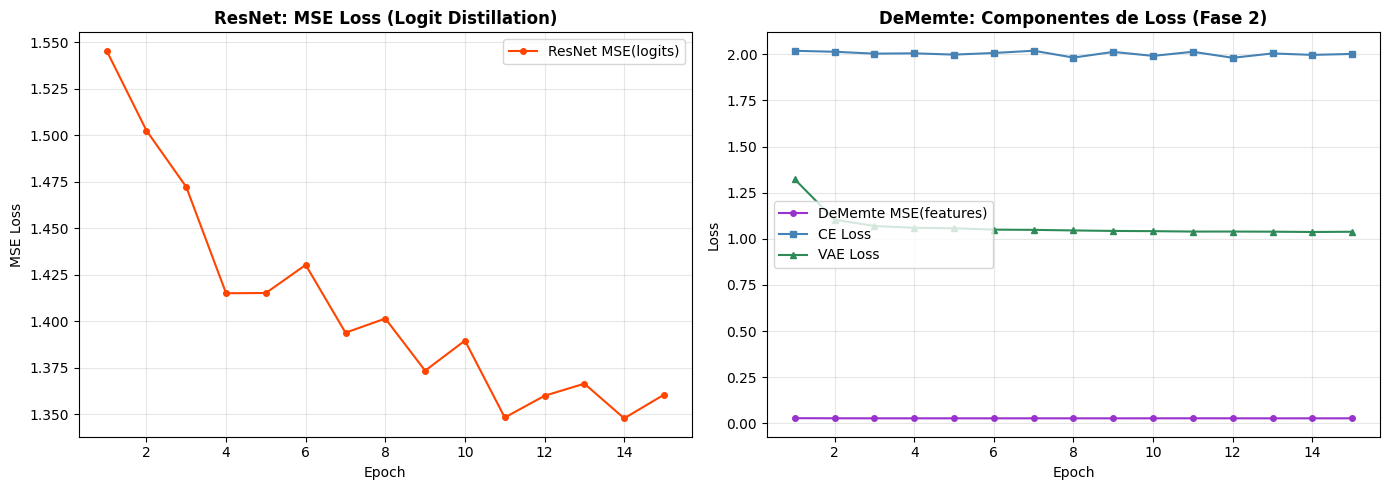

In [ ]:
# -- Evolucion del MSE Loss durante Fase 2 (ambos modelos) --------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ep2, history_resnet_p2['mse_loss'], '-o', markersize=4, color='orangered', label='ResNet MSE(logits)')
ax.set_title('ResNet: MSE Loss (Logit Distillation)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ep2, history_dm_p2['mse_loss'], '-o', markersize=4, color='darkorchid', label='DeMemte MSE(features)')
ax.plot(ep2, history_dm_p2['ce_loss'], '-s', markersize=4, color='steelblue', label='CE Loss')
ax.plot(ep2, history_dm_p2['vae_loss'], '-^', markersize=4, color='seagreen', label='VAE Loss')
ax.set_title('DeMemte: Componentes de Loss (Fase 2)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# -- Guardar modelos y metadata ------------------------------------------------

out_dir = '../out/dememte_distillation_flowers102'
os.makedirs(out_dir, exist_ok=True)

# DeMemte con destilacion
dm_path = os.path.join(out_dir, 'dememte_distillation_flowers102.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'metadata': {
        'variant': 'spatial_orthogonal_2phase_distillation',
        'dataset': 'Flowers102',
        'epochs_phase1': EPOCHS_P1,
        'epochs_phase2': EPOCHS_P2,
        'noise_std': NOISE_STD,
        'mse_weight': MSE_WEIGHT,
        'vae_weight': VAE_WEIGHT,
        'phase1_clean_acc': dm_p1_clean,
        'phase1_noisy_acc': dm_p1_noisy,
        'phase2_clean_acc': dm_p2_clean,
        'phase2_noisy_acc': dm_p2_noisy,
        'classifier_frozen_in_phase2': True,
        'distillation_level': 'features_1d_after_feat_norm',
    }
}, dm_path)

# ResNet con destilacion
rn_path = os.path.join(out_dir, 'resnet_distillation_baseline.pth')
torch.save({
    'model_state_dict': resnet.state_dict(),
    'metadata': {
        'model': 'resnet18_2phase_logit_distillation',
        'dataset': 'Flowers102',
        'epochs_phase1': EPOCHS_P1,
        'epochs_phase2': EPOCHS_P2,
        'noise_std': NOISE_STD,
        'mse_weight': MSE_WEIGHT,
        'phase1_clean_acc': resnet_p1_clean,
        'phase1_noisy_acc': resnet_p1_noisy,
        'phase2_clean_acc': resnet_p2_clean,
        'phase2_noisy_acc': resnet_p2_noisy,
        'distillation_level': 'logits',
    }
}, rn_path)

# Exportar resultados como JSON
results_json = {
    'experiment': 'orthogonal_memory_distillation',
    'date': '2026-02-28',
    'hyperparams': {
        'epochs_p1': EPOCHS_P1, 'epochs_p2': EPOCHS_P2,
        'noise_std': NOISE_STD, 'mse_weight': MSE_WEIGHT,
        'vae_weight': VAE_WEIGHT, 'batch_size': BATCH_SIZE,
    },
    'results': {k: v for k, v in results.items()},
    'histories': {
        'resnet_p1': history_resnet_p1,
        'resnet_p2': history_resnet_p2,
        'dememte_p1': history_dm_p1,
        'dememte_p2': history_dm_p2,
    }
}
json_path = os.path.join(out_dir, 'experiment_results.json')
with open(json_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f'Saved: {dm_path}')
print(f'Saved: {rn_path}')
print(f'Saved: {json_path}')

Saved: ../out/dememte_distillation_flowers102/dememte_distillation_flowers102.pth
Saved: ../out/dememte_distillation_flowers102/resnet_distillation_baseline.pth
Saved: ../out/dememte_distillation_flowers102/experiment_results.json
